# RideWise - Feature Engineering
 - Transform clean riders and trips data that can help have a better churn prediction
 - Engineer 20 + features 
 - (1) RFM framework + (2) Behavioral + (3) Temporal signals

#### Step 1 - Setup 

In [1]:
### Setup & import libraries

import os, warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
%matplotlib inline
sns.set_theme(style="whitegrid", font_scale=1.2)


# define the data paths
DATA_PROCESSED = os.path.join("..", "data", "processed")

# load the datasets
riders = pd.read_csv(os.path.join(DATA_PROCESSED, "riders_clean.csv"), parse_dates=["signup_date"])
drivers = pd.read_csv(os.path.join(DATA_PROCESSED, "drivers_clean.csv"))
trips = pd.read_csv(os.path.join(DATA_PROCESSED, "trips_clean.csv"), parse_dates=["pickup_time", "dropoff_time"])
sessions = pd.read_csv(os.path.join(DATA_PROCESSED, "sessions_clean.csv"), parse_dates=["session_time"])



In [2]:
# step 1b - Confirm the datasets loaded correctly
datasets = {
    "Riders": riders,
    "Trips": trips,
    "Drivers": drivers,
    "Sessions": sessions
}

for name, df in datasets.items():

    print(
        f"{name:<10}: "
        f"{df.shape[0]:,} rows × "
        f"{df.shape[1]} columns"
    )

Riders    : 10,000 rows × 8 columns
Trips     : 200,000 rows × 17 columns
Drivers   : 5,000 rows × 7 columns
Sessions  : 50,000 rows × 8 columns


In [3]:
# Step 1c — Inspect date ranges

# Churn prediction is a time-dependent problem.

# Before defining observation and prediction windows, we must understand:

# when rider accounts were created;
# the first and last trip dates;
# the session activity period;
# whether the available data provides enough future time to measure churn.

# Convert timestamp columns consistently

# step 1d - Riders dates

riders["signup_date"] = pd.to_datetime(
    riders["signup_date"],
    errors="coerce"
)
# Step 1e — Trip dates
trip_date_cols = [
    "pickup_time",
    "dropoff_time"
]

for col in trip_date_cols:

    trips[col] = pd.to_datetime(
        trips[col],
        errors="coerce"
    )
# Step 1f — Driver dates

driver_date_cols = [
    col
    for col in ["join_date", "last_active"]
    if col in drivers.columns
]

for col in driver_date_cols:

    drivers[col] = pd.to_datetime(
        drivers[col],
        errors="coerce"
    )

# Step 1g — Session dates

sessions["session_time"] = pd.to_datetime(
    sessions["session_time"],
    errors="coerce"
)

In [4]:
# step 1h-  Confirm the datetime conversions
print("Riders")
print(riders["signup_date"].dtype)

print("\nTrips")
print(trips[trip_date_cols].dtypes)

print("\nDrivers")
print(drivers[driver_date_cols].dtypes)

print("\nSessions")
print(sessions["session_time"].dtype)

Riders
datetime64[us]

Trips
pickup_time     datetime64[us]
dropoff_time    datetime64[us]
dtype: object

Drivers
last_active    datetime64[us]
dtype: object

Sessions
datetime64[us]


### STEP 2 - check available timeline

- determine if 30-day, 60-day or 90-day prediction window is realistic.


In [5]:

date_ranges = pd.DataFrame({
    "Dataset": [
        "Riders",
        "Trips",
        "Sessions"
    ],

    "Start Date": [
        riders["signup_date"].min(),
        trips["pickup_time"].min(),
        sessions["session_time"].min()
    ],

    "End Date": [
        riders["signup_date"].max(),
        trips["pickup_time"].max(),
        sessions["session_time"].max()
    ]
})

date_ranges

,Dataset,Start Date,End Date
0,Riders,2023-04-27 00:00:00,2025-04-26 00:00:00
1,Trips,2024-04-26 21:40:34,2025-04-27 23:43:26
2,Sessions,2025-04-26 21:33:06,2025-04-27 23:45:59


In [6]:
# step 2b - calculate the Duration days

date_ranges["Duration Days"] = (
    date_ranges["End Date"] -
    date_ranges["Start Date"]
).dt.days

date_ranges

,Dataset,Start Date,End Date,Duration Days
0,Riders,2023-04-27 00:00:00,2025-04-26 00:00:00,730
1,Trips,2024-04-26 21:40:34,2025-04-27 23:43:26,366
2,Sessions,2025-04-26 21:33:06,2025-04-27 23:45:59,1


### step 2c - Define the Modelling Cutoff

- We  reserve the final 60 days of trip history for measuring churn.

- Timeline
- Historical period                        Future period
- Feature creation                         Target creation

- |--------------------------------------|---------------|
                                       ^

                              
                                        Prediction cutoff


In [7]:

# step 2d -  Define the dates

dataset_end_date = trips["pickup_time"].max()

prediction_window_days = 60

prediction_start_date = (
    dataset_end_date -
    pd.Timedelta(days=prediction_window_days)
)

print(f"Trip data ends        : {dataset_end_date}")
print(f"Prediction starts     : {prediction_start_date}")
print(f"Prediction window     : {prediction_window_days} days")

Trip data ends        : 2025-04-27 23:43:26
Prediction starts     : 2025-02-26 23:43:26
Prediction window     : 60 days


In [8]:
# step 2e - Split Historical and Future Trips

# pickup_time < prediction_start_date for historical trips and:

# pickup_time >= prediction_start_date for future trips


historical_trips = trips[
    trips["pickup_time"] < prediction_start_date
].copy()

future_trips = trips[
    trips["pickup_time"] >= prediction_start_date
].copy()

# step 2f - Validate the split:

print(
    f"Historical trips : "
    f"{historical_trips.shape[0]:,}"
)

print(
    f"Future trips     : "
    f"{future_trips.shape[0]:,}"
)


Historical trips : 167,345
Future trips     : 32,655


In [9]:
# step 2g - summary statistics
future_trips.groupby("user_id").size().describe()

count    9614.000000
mean        3.396609
std         1.723553
min         1.000000
25%         2.000000
50%         3.000000
75%         4.000000
max        12.000000
dtype: float64

In [10]:
 # step 2h -  confirm split


print("Historical riders:", historical_trips["user_id"].nunique())
print("Future riders:", future_trips["user_id"].nunique())

Historical riders: 10000
Future riders: 9614


### STEP 3 - Create the Behavioural Churn Target

- A rider is defined as churned when they completed no trip during the future 60-day window.


In [11]:
# step 3a - define active riders

active_future_riders = set(
    future_trips["user_id"].unique()
)

In [12]:
# step 3b - Create one target row per rider:
churn_target = riders[
    ["user_id"]
].copy()

In [13]:
# step 3c -  Create the churn label:

# 0 = Active during the future period
# 1 = No trips during the future period

churn_target["churned"] = (
    ~churn_target["user_id"]
    .isin(active_future_riders)
).astype(int)




### Validate the Target


In [14]:
# step 3d - Target counts
churn_target["churned"].value_counts()

churned
0    9614
1     386
Name: count, dtype: int64

In [15]:
#  step 3e - Target percentages
churn_distribution = (
    churn_target["churned"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
    .rename_axis("churned")
    .reset_index(name="percentage")
)

churn_distribution

,churned,percentage
0,0,96.14
1,1,3.86


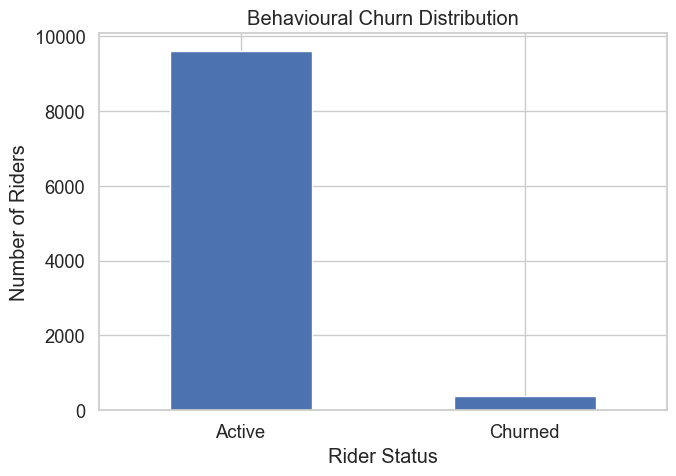

In [16]:
# step 3f - Visualize the Target

target_plot = (
    churn_target["churned"]
    .map({
        0: "Active",
        1: "Churned"
    })
    .value_counts()
)

target_plot.plot(
    kind="bar",
    figsize=(7, 5)
)

plt.title(
    "Behavioural Churn Distribution"
)

plt.xlabel(
    "Rider Status"
)

plt.ylabel(
    "Number of Riders"
)

plt.xticks(
    rotation=0
)

plt.tight_layout()
plt.show()


### STEP 4 - Customer Feature Table

In [17]:
# step 4a -  Create Customer Features

# A rider's demographic and account information can influence their likelihood of churning.

# For example:

# New customers may churn more frequently than long-term customers.
# Loyalty programme members may be more likely to stay.
# Referral customers may behave differently from customers acquired through other channels.

# Create customer-level features from the riders dataset only:

# Account age
# Was referred
# Loyalty status
# City
# Average rating given

# step create a copy of dataframe

customer_features = riders.copy()

In [18]:
# step 4b -  Calculate Account Age

# At prediction time, we only know information available up to the prediction date. 

# Calculating account age using the prediction start date prevents future information from leaking into the model.

# we calculate riders account age at the start of the prediction window

# Example:

# Imagine we're predicting churn on 26 February 2025.

# We only know how long the rider had been registered up to that date.

# Using today's date would leak future information.

customer_features["account_age_days"] = (
    prediction_start_date -
    customer_features["signup_date"]
).dt.days

In [19]:
# step 4c - validate account age
customer_features["account_age_days"].describe().round(2)

count    10000.00
mean       304.98
std        211.29
min        -59.00
25%        118.00
50%        307.00
75%        488.00
max        671.00
Name: account_age_days, dtype: float64

In [20]:
# step 4d- Remove Negative Values

# Some riders may have signed up after the prediction start date.

# These riders had no opportunity to churn and should not be included.

customer_features = customer_features[
    customer_features["account_age_days"] >= 0
].copy()

# step 4e - Check how many riders are left:

customer_features.shape

(9204, 9)

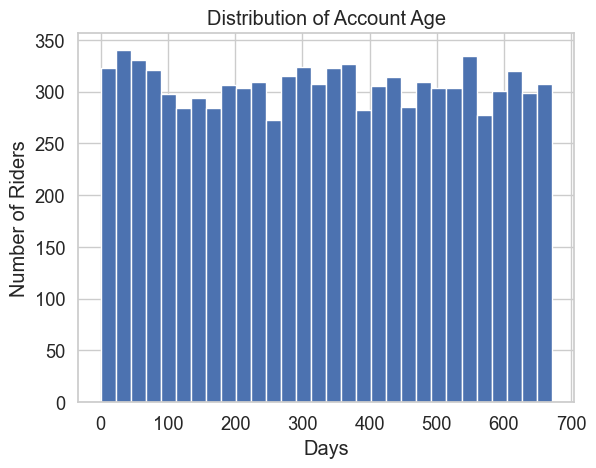

In [21]:
# step 4f - Inspect Account Age
customer_features["account_age_days"].hist(
    bins=30
)

plt.title("Distribution of Account Age")

plt.xlabel("Days")

plt.ylabel("Number of Riders")

plt.show()

### Insight:
- Most riders have established accounts, while a smaller proportion are relatively new users. 
- Account age may therefore help distinguish loyal customers from newer riders who have had less time to develop regular usage patterns.

In [22]:
# step 4g - Select Customer Features

# we Keep only the variables we want to use later.

customer_features = customer_features[
    [
        "user_id",
        "account_age_days",
        "age",
        "city",
        "loyalty_status",
        "avg_rating_given",
        "was_referred"
    ]
]


customer_features.head()

,user_id,account_age_days,age,city,loyalty_status,avg_rating_given,was_referred
0,R00000,33,35,Nairobi,Bronze,5.0,1
1,R00001,170,35,Nairobi,Bronze,4.7,0
2,R00002,172,47,Lagos,Bronze,4.2,0
4,R00004,190,41,Lagos,Silver,3.9,1
5,R00005,597,40,Lagos,Bronze,5.0,0


In [23]:
# step 4f -  validate feature table

print(customer_features.isna().sum())
print(customer_features.info())

user_id             0
account_age_days    0
age                 0
city                0
loyalty_status      0
avg_rating_given    0
was_referred        0
dtype: int64
<class 'pandas.DataFrame'>
Index: 9204 entries, 0 to 9998
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   user_id           9204 non-null   str    
 1   account_age_days  9204 non-null   int64  
 2   age               9204 non-null   int64  
 3   city              9204 non-null   str    
 4   loyalty_status    9204 non-null   str    
 5   avg_rating_given  9204 non-null   float64
 6   was_referred      9204 non-null   int64  
dtypes: float64(1), int64(3), str(3)
memory usage: 736.4 KB
None


### STEP 5 -  RFM Features

- Past customer behaviour is one of the strongest predictors of future behaviour.

- RFM summarises three important aspects of each rider:

- Recency – How recently did the rider complete a trip?
- Frequency – How often does the rider use RideWise?
- Monetary – How much has the rider spent?

In [24]:
# step 5a - Create the RFM Base Table (We aggregate only the historical trips.)

rfm_features = (
    historical_trips
    .groupby("user_id")
    .agg(
        last_trip=("pickup_time", "max"),
        trip_count=("trip_id", "count"),
        total_spend=("fare", "sum"),
        average_fare=("fare", "mean")
    )
    .reset_index()
)

rfm_features.head()

,user_id,last_trip,trip_count,total_spend,average_fare
0,R00000,2025-02-18 04:44:51,24,349.74,14.572500
1,R00001,2025-01-12 21:50:01,11,138.24,12.567273
2,R00002,2025-02-15 06:14:54,20,328.09,16.404500
3,R00003,2025-02-25 04:22:32,9,121.47,13.496667
4,R00004,2025-02-23 08:27:42,14,236.95,16.925000


In [25]:
# step 5b - Rename for Clarity
rfm_features = rfm_features.rename(
    columns={
        "trip_count": "frequency",
        "total_spend": "monetary_total"
    }
)

In [26]:
# step 5c -  Calculate Recency

# Recency is the number of days between the rider's last historical trip and the start of the prediction window.

rfm_features["recency_days"] = (
    prediction_start_date -
    rfm_features["last_trip"]
).dt.days

# Validate:

rfm_features["recency_days"].describe().round(2)

count    10000.00
mean        17.72
std         18.41
min          0.00
25%          5.00
50%         12.00
75%         25.00
max        179.00
Name: recency_days, dtype: float64

In [27]:
# step 5d - Create Average Spend Per Trip
rfm_features["average_spend_per_trip"] = (
    rfm_features["monetary_total"] /
    rfm_features["frequency"]
)

In [28]:
# step 5e - Remove Temporary Column

# The last_trip column was only needed to calculate recency.

rfm_features = rfm_features.drop(
    columns="last_trip"
)

# Step 5f  – Validate the Features
print(rfm_features.describe().round(2))

# step 5g - Check missing values:

print(rfm_features.isna().sum())

       frequency  monetary_total  average_fare  recency_days  \
count   10000.00        10000.00      10000.00      10000.00   
mean       16.73          257.71         15.40         17.72   
std         4.13           68.60          1.55         18.41   
min         4.00           59.69         10.51          0.00   
25%        14.00          209.43         14.32          5.00   
50%        17.00          253.80         15.28         12.00   
75%        19.00          301.74         16.37         25.00   
max        35.00          590.59         22.78        179.00   

       average_spend_per_trip  
count                10000.00  
mean                    15.40  
std                      1.55  
min                     10.51  
25%                     14.32  
50%                     15.28  
75%                     16.37  
max                     22.78  
user_id                   0
frequency                 0
monetary_total            0
average_fare              0
recency_days           

In [29]:
# step 5h - Merge with Customer Features

customer_features = customer_features.merge(
    rfm_features,
    on="user_id",
    how="left"
)

# 5i - Check the result:

customer_features.head()

,user_id,account_age_days,age,city,loyalty_status,avg_rating_given,was_referred,frequency,monetary_total,average_fare,recency_days,average_spend_per_trip
0,R00000,33,35,Nairobi,Bronze,5.0,1,24,349.74,14.572500,8,14.572500
1,R00001,170,35,Nairobi,Bronze,4.7,0,11,138.24,12.567273,45,12.567273
2,R00002,172,47,Lagos,Bronze,4.2,0,20,328.09,16.404500,11,16.404500
3,R00004,190,41,Lagos,Silver,3.9,1,14,236.95,16.925000,3,16.925000
4,R00005,597,40,Lagos,Bronze,5.0,0,17,249.76,14.691765,5,14.691765


### STEP 6 -  Trip Behaviour Features

- RFM tells us how much and how often a rider uses RideWise, but it doesn't tell us how they use the service.

- Trip behaviour can reveal patterns such as:

- Does the rider travel during peak hours?
- Do they mainly ride at weekends?
- Do they experience surge pricing?
- How long are their trips?
- How generous are they with tips?

In [30]:
# step 6a - Create Behavioural Variables

# Peak-hour trips

# Morning: 7-9 AM

# Evening: 4-7 PM

historical_trips["trip_hour"] = (
    historical_trips["pickup_time"].dt.hour
)

historical_trips["is_peak"] = np.where(
    historical_trips["trip_hour"].isin(
        [7, 8, 9, 16, 17, 18, 19]
    ),
    1,
    0
)

In [31]:
# step 6b - Weekend trips
historical_trips["day_of_week"] = (
    historical_trips["pickup_time"].dt.dayofweek
)

historical_trips["is_weekend"] = np.where(
    historical_trips["day_of_week"] >= 5,
    1,
    0
)

# step 6c - Rainy-weather trips
historical_trips["is_rainy"] = np.where(
    historical_trips["weather"] == "Rainy",
    1,
    0
)





### STEP 7 - Customer Engagement features

- Customer engagement reflects how actively a rider uses the RideWise platform.

- Customers who ride frequently and consistently are generally less likely to churn than those whose usage declines over time.

- The following behavioural features are engineered:

- Trips in the last 30 days
- Trips in the last 60 days
- Trips in the last 90 days
- Average days between trips
- Monthly trip frequency
- Customer Lifetime Value (CLV)


In [32]:
# step 7a - Customer Engagement Features

last_30_days = (
    prediction_start_date -
    pd.Timedelta(days=30)
)

trips_last_30 = (
    historical_trips[
        historical_trips["pickup_time"] >= last_30_days
    ]
    .groupby("user_id")
    .size()
    .rename("trips_last_30_days")
)

In [33]:
# step 7b - Trips in the Last 60 Days
last_60_days = (
    prediction_start_date -
    pd.Timedelta(days=60)
)

trips_last_60 = (
    historical_trips[
        historical_trips["pickup_time"] >= last_60_days
    ]
    .groupby("user_id")
    .size()
    .rename("trips_last_60_days")
)

In [34]:
 # step 7c - Trips in the Last 90 Days
last_90_days = (
    prediction_start_date -
    pd.Timedelta(days=90)
)

trips_last_90 = (
    historical_trips[
        historical_trips["pickup_time"] >= last_90_days
    ]
    .groupby("user_id")
    .size()
    .rename("trips_last_90_days")
)



In [35]:
# step 7e - Calculate Tip Rate

# Rather than using the total tip, we calculate the proportion of the fare that was tipped.

historical_trips["tip_rate"] = (
    historical_trips["tip"] /
    historical_trips["fare"]
)

# step 7f -  Remove impossible values:

historical_trips["tip_rate"] = (
    historical_trips["tip_rate"]
    .replace([np.inf, -np.inf], np.nan)
)

In [36]:
# step 7g - Aggregate Behaviour Features
trip_behaviour = (
    historical_trips
    .groupby("user_id")
    .agg(
        avg_trip_duration=(
            "trip_duration_minutes",
            "mean"
        ),
        avg_surge_multiplier=(
            "surge_multiplier",
            "mean"
        ),
        avg_tip=(
            "tip",
            "mean"
        ),
        avg_tip_rate=(
            "tip_rate",
            "mean"
        ),
        peak_trip_ratio=(
            "is_peak",
            "mean"
        ),
        weekend_trip_ratio=(
            "is_weekend",
            "mean"
        ),
        rainy_trip_ratio=(
            "is_rainy",
            "mean"
        )
    )
    .reset_index()
)

In [37]:
# step 7h - Average Days Between Trips

# Customers with long gaps between trips are often more likely to churn.

trip_gap = (
    historical_trips
    .sort_values(["user_id", "pickup_time"])
)

trip_gap["days_between_trips"] = (
    trip_gap
    .groupby("user_id")["pickup_time"]
    .diff()
    .dt.days
)

avg_trip_gap = (
    trip_gap
    .groupby("user_id")["days_between_trips"]
    .mean()
    .rename("avg_days_between_trips")
)

In [38]:
# step 7i - Monthly Trip Frequency

# Overall trip count can be misleading because some customers have been with RideWise much longer.

# Normalizing by account age makes the feature fairer.

# step 7j - Account age in months
customer_features["account_age_months"] = (
    customer_features["account_age_days"] / 30.44
)

# step 7k - Trip frequency
customer_features["trip_frequency_monthly"] = np.where(
    customer_features["account_age_months"] > 0,
    customer_features["frequency"] /
    customer_features["account_age_months"],
    0
)

In [39]:
# step 7l - Customer Lifetime Value (CLV)

# This estimates how much value a customer generates per day of membership.

customer_features["customer_lifetime_value"] = np.where(
    customer_features["account_age_days"] > 0,
    customer_features["monetary_total"] /
    customer_features["account_age_days"],
    0
)

In [40]:
# step 7m - Merge the New Features
customer_features = (
    customer_features
    .merge(
        trips_last_30,
        on="user_id",
        how="left"
    )
    .merge(
        trips_last_60,
        on="user_id",
        how="left"
    )
    .merge(
        avg_trip_gap,
        on="user_id",
        how="left"
    )
    .merge(
        trips_last_90,
        on="user_id",
        how="left"
    )
    
)

In [41]:
# step 7n -  Fill Missing Values

# Missing values here simply mean the rider had no trips in that period or not enough trips to calculate a gap.

engagement_features = [
    "trips_last_30_days",
    "trips_last_60_days",
    "avg_days_between_trips",
    "trips_last_90_days"
]

customer_features[engagement_features] = (
    customer_features[engagement_features]
    .fillna(0)
)

In [42]:
# step 7o -  Preferred Payment Method

# A rider's most frequently used payment method may reflect their habits.

preferred_payment = (
    historical_trips
    .groupby("user_id")["payment_type"]
    .agg(
        lambda x: x.mode().iat[0]
        if not x.mode().empty
        else np.nan
    )
    .reset_index()
    .rename(
        columns={
            "payment_type":
            "preferred_payment"
        }
    )
)



In [43]:
# step 7p -  Merge :

trip_behaviour = trip_behaviour.merge(
    preferred_payment,
    on="user_id",
    how="left"
)

# Merge with Customer Features
customer_features = customer_features.merge(
    trip_behaviour,
    on="user_id",
    how="left"
)

customer_features.info()


<class 'pandas.DataFrame'>
RangeIndex: 9204 entries, 0 to 9203
Data columns (total 27 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   user_id                  9204 non-null   str    
 1   account_age_days         9204 non-null   int64  
 2   age                      9204 non-null   int64  
 3   city                     9204 non-null   str    
 4   loyalty_status           9204 non-null   str    
 5   avg_rating_given         9204 non-null   float64
 6   was_referred             9204 non-null   int64  
 7   frequency                9204 non-null   int64  
 8   monetary_total           9204 non-null   float64
 9   average_fare             9204 non-null   float64
 10  recency_days             9204 non-null   int64  
 11  average_spend_per_trip   9204 non-null   float64
 12  account_age_months       9204 non-null   float64
 13  trip_frequency_monthly   9204 non-null   float64
 14  customer_lifetime_value  9204 non-n

In [44]:
# step 7p (i)- Validate the features
customer_features[
    [
        "avg_trip_duration",
        "avg_surge_multiplier",
        "avg_tip_rate",
        "peak_trip_ratio",
        "weekend_trip_ratio",
        "rainy_trip_ratio"
    ]
].describe().round(2)

,avg_trip_duration,avg_surge_multiplier,avg_tip_rate,peak_trip_ratio,weekend_trip_ratio,rainy_trip_ratio
count,9204.00,9204.00,9204.00,9204.00,9204.00,9204.00
mean,31.97,1.14,0.03,0.41,0.29,0.20
std,3.98,0.06,0.02,0.15,0.11,0.10
min,16.25,1.00,0.00,0.00,0.00,0.00
25%,29.33,1.10,0.02,0.30,0.21,0.13
50%,32.00,1.14,0.03,0.40,0.29,0.20
75%,34.61,1.18,0.04,0.50,0.36,0.26
max,47.18,1.46,0.19,1.00,0.86,0.78


In [45]:
# step 7p(ii)- Check Missing Values
behaviour_cols = [
    "avg_trip_duration",
    "avg_surge_multiplier",
    "avg_tip",
    "avg_tip_rate",
    "peak_trip_ratio",
    "weekend_trip_ratio",
    "rainy_trip_ratio",
    "preferred_payment"
]

customer_features[
    behaviour_cols
].isna().sum()

avg_trip_duration       0
avg_surge_multiplier    0
avg_tip                 0
avg_tip_rate            0
peak_trip_ratio         0
weekend_trip_ratio      0
rainy_trip_ratio        0
preferred_payment       0
dtype: int64

### STEP 8 -  Driver Features

- The quality of drivers a rider interacts with may influence their overall experience.

- For example:

- Riders consistently matched with highly rated drivers may be less likely to churn.
- Drivers with higher acceptance rates may reduce waiting times.
- More experienced drivers may provide better service.

In [46]:
# step 8a - Merge Historical Trips with Drivers
driver_trips = historical_trips.merge(
    drivers,
    on="driver_id",
    how="left"
)

driver_trips.head()

,trip_id,user_id,driver_id,fare,surge_multiplier,tip,payment_type,pickup_time,dropoff_time,pickup_lat,...,day_of_week,is_weekend,is_rainy,tip_rate,rating,vehicle_type,signup_date,last_active,city_y,acceptance_rate
0,T000000,R05207,D00315,12.11,1.0,0.00,Card,2024-11-27 16:14:50,2024-11-27 17:06:50,-1.108123,...,2,0,0,0.000000,4.1,Sedan,2024-07-21,2025-03-21 22:47:26.558938,Nairobi,0.549628
1,T000001,R09453,D03717,8.73,1.0,0.02,Card,2024-10-28 22:59:48,2024-10-28 23:12:48,6.675266,...,0,0,0,0.002291,4.9,SUV,2023-05-06,2025-04-12 08:36:21.207528,Lagos,0.629250
2,T000002,R00567,D02035,19.68,1.0,0.00,Card,2025-02-17 03:09:41,2025-02-17 03:25:41,-1.248589,...,0,0,0,0.000000,4.7,Sedan,2023-08-09,2025-04-19 05:19:12.026949,Nairobi,0.990000
3,T000003,R09573,D02657,16.43,1.0,0.01,Mobile Money,2024-06-18 17:22:14,2024-06-18 17:27:14,29.819554,...,1,0,0,0.000609,3.9,Sedan,2023-04-22,2025-02-08 22:15:23.685705,Cairo,0.247121
4,T000004,R03446,D01026,8.70,1.0,1.06,Card,2024-10-05 07:31:16,2024-10-05 08:01:16,-1.676479,...,5,1,0,0.121839,4.2,Sedan,2024-08-22,2025-04-13 11:24:50.358526,Nairobi,0.611031


In [47]:
# step 8b - Aggregate Driver Features


driver_features = (
    driver_trips
    .groupby("user_id")
    .agg(
        avg_driver_rating=(
            "rating",
            "mean"
        ),
        avg_driver_acceptance_rate=(
            "acceptance_rate",
            "mean"
        )
        
    )
    .reset_index()
)

driver_features.head()

,user_id,avg_driver_rating,avg_driver_acceptance_rate
0,R00000,4.241667,0.699978
1,R00001,4.145455,0.718857
2,R00002,4.110000,0.612854
3,R00003,4.111111,0.701391
4,R00004,4.214286,0.758234


In [48]:
# step 8c - Preferred Vehicle Type


preferred_vehicle = (
    driver_trips
    .groupby("user_id")["vehicle_type"]
    .agg(
        lambda x: x.mode().iat[0]
        if not x.mode().empty
        else np.nan
    )
    .reset_index()
    .rename(
        columns={
            "vehicle_type": "preferred_vehicle"
        }
    )
)

In [49]:
# step 8d -  Merge 

driver_features = driver_features.merge(
    preferred_vehicle,
    on="user_id",
    how="left"
)

In [50]:
# Merge with Customer Features
customer_features = customer_features.merge(
    driver_features,
    on="user_id",
    how="left"
)

In [51]:
# step 8e - Validate
print(customer_features.info())

driver_cols = [
    "avg_driver_rating",
    "avg_driver_acceptance_rate",
    "preferred_vehicle"
]



<class 'pandas.DataFrame'>
RangeIndex: 9204 entries, 0 to 9203
Data columns (total 30 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   user_id                     9204 non-null   str    
 1   account_age_days            9204 non-null   int64  
 2   age                         9204 non-null   int64  
 3   city                        9204 non-null   str    
 4   loyalty_status              9204 non-null   str    
 5   avg_rating_given            9204 non-null   float64
 6   was_referred                9204 non-null   int64  
 7   frequency                   9204 non-null   int64  
 8   monetary_total              9204 non-null   float64
 9   average_fare                9204 non-null   float64
 10  recency_days                9204 non-null   int64  
 11  average_spend_per_trip      9204 non-null   float64
 12  account_age_months          9204 non-null   float64
 13  trip_frequency_monthly      9204 non-null   

In [52]:
# step 8f - customer_features[driver_cols].isna().sum()

### STEP 9 - Session Features


- Trip behaviour tells us how riders use RideWise, but session data tells us how they interact with the app before booking.

- More engaged users often have a lower risk of churn.


In [53]:
# Step 9a – Create Historical Sessions
historical_sessions = sessions[
    sessions["session_time"] < prediction_start_date
].copy()

historical_sessions.shape

(0, 8)

In [54]:
# step 9b - Aggregate Session Behaviour

session_features = (
    historical_sessions
    .groupby("rider_id")
    .agg(
        session_count=(
            "session_id",
            "count"
        ),
        avg_time_on_app=(
            "time_on_app",
            "mean"
        ),
        total_time_on_app=(
            "time_on_app",
            "sum"
        ),
        avg_pages_visited=(
            "pages_visited",
            "mean"
        ),
        total_pages_visited=(
            "pages_visited",
            "sum"
        ),
        conversion_rate=(
            "converted",
            "mean"
        )
    )
    .reset_index()
)

In [55]:
# step 9c - Rename the Key

session_features = session_features.rename(
    columns={
        "rider_id": "user_id"
    }
)

In [56]:
# step 9d - Create an Engagement Score


session_features["engagement_score"] = (
    session_features["avg_time_on_app"] *
    session_features["avg_pages_visited"]
)

### session features excluded

- session dataset did not contain any records before the prediction cutoff date.

- therefore, historical session features could not be created without using future information.

- To avoid temporal data leakage , all session derived features  were excluded fro final modeling dataset

In [57]:

customer_features.columns.tolist()

['user_id',
 'account_age_days',
 'age',
 'city',
 'loyalty_status',
 'avg_rating_given',
 'was_referred',
 'frequency',
 'monetary_total',
 'average_fare',
 'recency_days',
 'average_spend_per_trip',
 'account_age_months',
 'trip_frequency_monthly',
 'customer_lifetime_value',
 'trips_last_30_days',
 'trips_last_60_days',
 'avg_days_between_trips',
 'trips_last_90_days',
 'avg_trip_duration',
 'avg_surge_multiplier',
 'avg_tip',
 'avg_tip_rate',
 'peak_trip_ratio',
 'weekend_trip_ratio',
 'rainy_trip_ratio',
 'preferred_payment',
 'avg_driver_rating',
 'avg_driver_acceptance_rate',
 'preferred_vehicle']

### STEP 10 - Merge the Churn Target

In [58]:
 # step 10a - Merge the Churn Target
model_data = customer_features.merge(
    churn_target,
    on="user_id",
    how="inner"
)

model_data.head()

,user_id,account_age_days,age,city,loyalty_status,avg_rating_given,was_referred,frequency,monetary_total,average_fare,...,avg_tip,avg_tip_rate,peak_trip_ratio,weekend_trip_ratio,rainy_trip_ratio,preferred_payment,avg_driver_rating,avg_driver_acceptance_rate,preferred_vehicle,churned
0,R00000,33,35,Nairobi,Bronze,5.0,1,24,349.74,14.572500,...,0.167917,0.012193,0.208333,0.166667,0.166667,Mobile Money,4.241667,0.699978,SUV,0
1,R00001,170,35,Nairobi,Bronze,4.7,0,11,138.24,12.567273,...,0.007273,0.000823,0.181818,0.181818,0.000000,Card,4.145455,0.718857,Sedan,0
2,R00002,172,47,Lagos,Bronze,4.2,0,20,328.09,16.404500,...,0.260500,0.021981,0.450000,0.100000,0.300000,Card,4.110000,0.612854,Sedan,0
3,R00004,190,41,Lagos,Silver,3.9,1,14,236.95,16.925000,...,0.670000,0.066116,0.285714,0.500000,0.214286,Mobile Money,4.214286,0.758234,Sedan,0
4,R00005,597,40,Lagos,Bronze,5.0,0,17,249.76,14.691765,...,0.213529,0.010792,0.411765,0.117647,0.058824,Mobile Money,4.023529,0.677242,Sedan,0


In [59]:
# step 10b  -  Clean any existing infinite values
model_data = model_data.replace(
    [np.inf, -np.inf],
    np.nan
)

print("Infinity values:", np.isinf(
    model_data.select_dtypes(include=np.number)
).sum().sum())

print("Missing values:", model_data.isna().sum().sum())

Infinity values: 0
Missing values: 0


In [60]:
# step 10c Validate the Dataset Shape
print("Final modelling dataset")
print("-" * 35)

print(f"Rows    : {model_data.shape[0]:,}")
print(f"Columns : {model_data.shape[1]}")




Final modelling dataset
-----------------------------------
Rows    : 9,204
Columns : 31


In [61]:
# step 10d - Check for Duplicate Riders
duplicates = model_data["user_id"].duplicated().sum()

print(f"Duplicate riders: {duplicates}")

Duplicate riders: 0


In [62]:
# step 10e - Check Missing Values
missing_summary = (
    model_data
    .isna()
    .sum()
    .to_frame("Missing")
)

missing_summary["Percentage"] = (
    missing_summary["Missing"]
    / len(model_data)
    * 100
).round(2)

missing_summary = missing_summary[
    missing_summary["Missing"] > 0
].sort_values(
    "Missing",
    ascending=False
)

missing_summary

,Missing,Percentage


In [63]:
# step 10f - Validate Data Types
model_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 9204 entries, 0 to 9203
Data columns (total 31 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   user_id                     9204 non-null   str    
 1   account_age_days            9204 non-null   int64  
 2   age                         9204 non-null   int64  
 3   city                        9204 non-null   str    
 4   loyalty_status              9204 non-null   str    
 5   avg_rating_given            9204 non-null   float64
 6   was_referred                9204 non-null   int64  
 7   frequency                   9204 non-null   int64  
 8   monetary_total              9204 non-null   float64
 9   average_fare                9204 non-null   float64
 10  recency_days                9204 non-null   int64  
 11  average_spend_per_trip      9204 non-null   float64
 12  account_age_months          9204 non-null   float64
 13  trip_frequency_monthly      9204 non-null   

In [64]:
# step 10g - Validate the Target
model_data["churned"].value_counts()

churned
0    8848
1     356
Name: count, dtype: int64

In [65]:
(
    model_data["churned"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

churned
0    96.13
1     3.87
Name: proportion, dtype: float64

In [66]:
# step 10h -  Save the Feature Dataset
model_data.to_csv(
    os.path.join(
        DATA_PROCESSED,
        "ridewise_features.csv"
    ),
    index=False
)

print("Feature dataset saved successfully.")
print("Historical riders:", historical_trips["user_id"].nunique())
print("Future riders:", future_trips["user_id"].nunique())

Feature dataset saved successfully.
Historical riders: 10000
Future riders: 9614
